In [ ]:
import os
import glob
import fnmatch
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import seaborn as sns
import IPython.display as ipd
import random

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from tensorflow.keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU, SimpleRNN, LSTM
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU, Dropout

from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay

In [48]:
df = pd.read_csv("hasta_etiketler.csv", sep=";")
df["Teshis"] = df["Teshis"].replace({
    "COPD4": "COPD",
    "COPD3": "COPD",
    "COPD2": "COPD",
    "COPD0": "COPD",
})
label_dict = dict(zip(df["ID"], df["Teshis"]))
label_dict["H001"] = "Healthy" 
label_dict

{'H001': 'Healthy',
 'H002': 'COPD',
 'H003': 'COPD',
 'H004': 'COPD',
 'H005': 'COPD',
 'H006': 'COPD',
 'H007': 'COPD',
 'H008': 'COPD',
 'H009': 'COPD',
 'H010': 'COPD',
 'H011': 'COPD',
 'H012': 'COPD',
 'H013': 'COPD',
 'H014': 'COPD',
 'H015': 'COPD',
 'H016': 'COPD',
 'H017': 'COPD1',
 'H018': 'COPD',
 'H019': 'Asthma',
 'H020': 'Asthma',
 'H021': 'COPD',
 'H022': 'COPD',
 'H023': 'COPD',
 'H024': 'COPD',
 'H025': 'COPD',
 'H026': 'COPD',
 'H027': 'Asthma',
 'H028': 'COPD',
 'H029': 'COPD1',
 'H030': 'COPD',
 'H031': 'COPD',
 'H032': 'COPD',
 'H033': 'COPD',
 'H034': 'COPD',
 'H035': 'COPD',
 'H036': 'COPD',
 'H037': 'COPD',
 'H038': 'COPD',
 'H039': 'COPD1',
 'H040': 'COPD',
 'H041': 'COPD',
 'H042': 'COPD',
 'H043': 'COPD1',
 'H044': 'COPD',
 'H045': 'COPD1',
 'H046': 'Asthma',
 'H047': 'Asthma',
 'H048': 'Healthy',
 'H049': 'Healthy',
 'H050': 'COPD',
 'H051': 'Asthma',
 'H052': 'Healthy',
 'H053': 'Healthy',
 'H054': 'Healthy',
 'H055': 'Healthy',
 'H056': 'Healthy',
 'H057'

In [49]:
asthma_data = "./Datalar/Asthma"
copd_data = "./Datalar/COPD4"
healthy_data = "./Datalar/Healthy"

print("Asthma files:", len(os.listdir(asthma_data)))
print("COPD files:", len(os.listdir(copd_data)))
print("Healthy files:", len(os.listdir(healthy_data)))

Asthma files: 96
COPD files: 112
Healthy files: 112


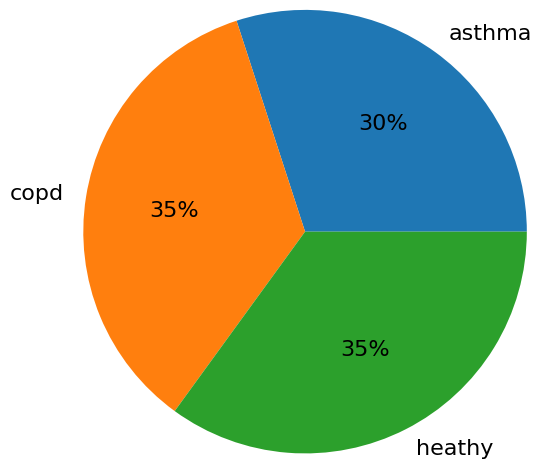

In [50]:
x = np.array([len(os.listdir(asthma_data)),
              len(os.listdir(copd_data)),
              len(os.listdir(healthy_data))])
labels = ['asthma', 'copd', 'heathy']
plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
plt.show()

In [51]:
def augment_noise(audio, sr=None):
    noise = np.random.randn(len(audio))
    return audio + 0.005 * noise

def augment_pitch(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-2, 2))

def augment_speed(audio, sr):
    speed = random.uniform(0.9, 1.1)
    return librosa.effects.time_stretch(audio, rate=speed)

def apply_augmentations(audio, sr=22050):
    funcs = [
        lambda y: augment_noise(y),
        lambda y: augment_pitch(y, sr),
        lambda y: augment_speed(y, sr)
    ]
    func = random.choice(funcs)
    return func(audio)


In [52]:
import nara_wpe.wpe as wpe


def apply_wpe(audio, sr=22050):

    audio = np.expand_dims(audio, axis=0)   # (mic, samples)

    enhanced = wpe.wpe(
        audio,
        taps=10,
        delay=3,
        iterations=5
    )

    return enhanced[0]



def extract_mfcc(audio, sr=22050):
    audio = apply_wpe(audio, sr)

    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr,
        n_mfcc=52, n_fft=2048, hop_length=512
    )
    return mfcc.T


In [53]:
class_folders = {
    "Asthma": asthma_data,
    "COPD": copd_data,
    "Healthy": healthy_data
}

X_features = []
y_labels = []

for label, folder in class_folders.items():
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        audio, sr = librosa.load(path, sr=22050)

        # Orijinal
        X_features.append(extract_mfcc(audio))
        y_labels.append(label)

        # Augmented
        audio_aug = apply_augmentations(audio)
        X_features.append(extract_mfcc(audio_aug))
        y_labels.append(label)


In [54]:

X_padded = pad_sequences(
    X_features,
    padding="post",
    dtype="float32"
)

X = np.array(X_padded)
y = np.array(y_labels)


In [55]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)


In [57]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


In [58]:
def build_mlp(input_dim, num_classes=3, lr=1e-4):
    model = Sequential([
        Dense(512, input_dim=input_dim, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [59]:
def build_lstm(input_shape, num_classes=3):
    model = Sequential()
    model.add(LSTM(128, return_sequences=False, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [60]:
def build_svm(input_dim, num_classes=3, C=10, kernel='rbf'):
    model = SVC(
        C=C,
        kernel=kernel,
        gamma='scale',
        probability=True
    )
    return model


In [61]:
def build_knn(input_dim, num_classes=3, k=5):
    model = KNeighborsClassifier(n_neighbors=k)
    return model

In [62]:
def build_cnn(input_shape, num_classes=3):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(Conv1D(128, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [63]:
seq_input = (X_train.shape[1], X_train.shape[2])  # (time, 52)
flat_input = X_train_flat.shape[1]
num_classes = y_train.shape[1]


In [64]:
models = {
    "MLP": build_mlp(flat_input, num_classes),
    "LSTM": build_lstm(seq_input, num_classes),
    "SVM": build_svm(flat_input, num_classes),
    "CNN": build_cnn(seq_input, num_classes),
    "KNN": build_knn(flat_input, num_classes),
}

results = {}

for name, model in models.items():
    print("\nTraining:", name)

    if name in ["MLP", "CNN", "LSTM"]:
        model.fit(X_train_flat if name=="MLP" else X_train,
                  y_train,
                  validation_data=(X_test_flat, y_test) if name=="MLP" else (X_test, y_test),
                  epochs=100, batch_size=32, verbose=0)

        preds = np.argmax(model.predict(X_test_flat if name=="MLP" else X_test), axis=1)

    else:  # SVM, KNN
        model.fit(X_train_flat, y_train.argmax(axis=1))
        preds = model.predict(X_test_flat)

    y_true = y_test.argmax(axis=1)
    f1 = f1_score(y_true, preds, average="weighted")
    results[name] = f1
    print("F1 Score:", f1)
    print(classification_report(y_true, preds))

# KNN ======================================================================

""" print("\nTraining: KNN")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train.argmax(axis=1))

knn_preds = knn.predict(X_test_flat)

knn_f1 = f1_score(y_test.argmax(axis=1), knn_preds, average="weighted")
results["KNN"] = knn_f1

print("F1 Score:", knn_f1)
print(classification_report(y_test.argmax(axis=1), knn_preds))

cm = confusion_matrix(y_test.argmax(axis=1), knn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show() """



# SVM ======================================================================

""" print("\nTraining: SVM")
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_flat, y_train.argmax(axis=1))

svm_preds = svm.predict(X_test_flat)

svm_f1 = f1_score(y_test.argmax(axis=1), svm_preds, average="weighted")
results["SVM"] = svm_f1

print("F1 Score:", svm_f1)
print(classification_report(y_test.argmax(axis=1), svm_preds))

cm = confusion_matrix(y_test.argmax(axis=1), svm_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show() """


c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the


Training: MLP
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
F1 Score: 0.7358744579562595
              precision    recall  f1-score   support

           0       0.65      0.68      0.67        41
           1       0.73      0.96      0.83        45
           2       0.92      0.57      0.71        42

    accuracy                           0.74       128
   macro avg       0.77      0.74      0.73       128
weighted avg       0.77      0.74      0.74       128


Training: LSTM
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step
F1 Score: 0.19921875000000003
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.35      1.00      0.52        45
           2       1.00      0.02      0.05        42

    accuracy                           0.36       128
   macro avg       0.45      0.34      0.19       128
weighted avg       0.45      0.36      0.20       128


Training: SVM


c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

F1 Score: 0.7114108571556994
              precision    recall  f1-score   support

           0       0.71      0.54      0.61        41
           1       0.59      0.76      0.66        45
           2       0.90      0.83      0.86        42

    accuracy                           0.71       128
   macro avg       0.73      0.71      0.71       128
weighted avg       0.73      0.71      0.71       128


Training: CNN
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
F1 Score: 0.763780525030525
              precision    recall  f1-score   support

           0       0.65      0.78      0.71        41
           1       0.70      0.71      0.70        45
           2       1.00      0.79      0.88        42

    accuracy                           0.76       128
   macro avg       0.78      0.76      0.76       128
weighted avg       0.78      0.76      0.76       128


Training: KNN
F1 Score: 0.6499219691768681
              precision    recall  f1-score   support

           0       0.51      

' print("\nTraining: SVM")\nsvm = SVC(kernel=\'rbf\', probability=True)\nsvm.fit(X_train_flat, y_train.argmax(axis=1))\n\nsvm_preds = svm.predict(X_test_flat)\n\nsvm_f1 = f1_score(y_test.argmax(axis=1), svm_preds, average="weighted")\nresults["SVM"] = svm_f1\n\nprint("F1 Score:", svm_f1)\nprint(classification_report(y_test.argmax(axis=1), svm_preds))\n\ncm = confusion_matrix(y_test.argmax(axis=1), svm_preds)\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm)\ndisp.plot()\nplt.title("SVM Confusion Matrix")\nplt.show() '

In [65]:
cnn_model = build_cnn(seq_input, num_classes)
cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=100, batch_size=32, verbose=1)

y_pred_proba = cnn_model.predict(X_test)   # (N, 3)

y_pred = np.argmax(y_pred_proba, axis=1)   # (N,)


Epoch 1/100


c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.5020 - loss: 7.4705 - val_accuracy: 0.5000 - val_loss: 5.1822
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.6934 - loss: 1.5984 - val_accuracy: 0.5938 - val_loss: 1.1616
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.7012 - loss: 0.6996 - val_accuracy: 0.5391 - val_loss: 1.5853
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.7578 - loss: 0.7062 - val_accuracy: 0.5312 - val_loss: 1.1386
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.7773 - loss: 0.5534 - val_accuracy: 0.6641 - val_loss: 0.8097
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.7676 - loss: 0.5256 - val_accuracy: 0.7266 - val_loss: 0.7416
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.7852 - loss: 0.5050 - val_accuracy: 0.7422 - val_loss: 0.7371
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.8516 - loss: 0.3891 - val_accuracy: 0.7812

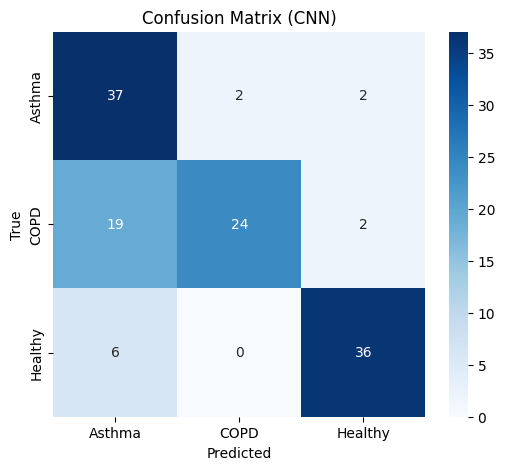

In [66]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CNN)")
plt.show()


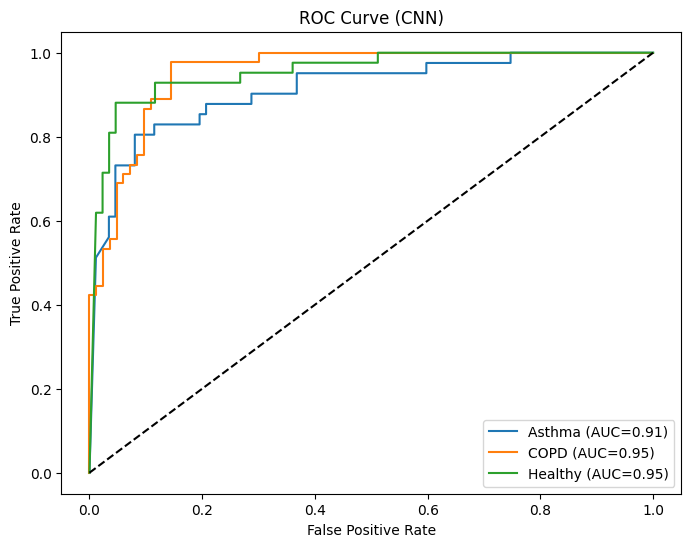

In [67]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN)")
plt.legend()
plt.show()
